<a href="https://colab.research.google.com/github/Kate6097/train/blob/main/%D0%92%D0%B0%D0%BB%D0%B8%D0%B4%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
# Установка дополнительных библиотек
!pip install Ninja

# Импорт нужных библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import save_image
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

!pip install pydrive2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ifcj76b4
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ifcj76b4
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from torchvision.transforms import Resize, Normalize

In [ ]:
import copy
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

!git clone https://github.com/rosinality/stylegan2-pytorch.git
%cd stylegan2-pytorch

!pip install ninja

import os
os.environ['STYLEGAN2_PYTORCH_FORCE_PURE'] = '1'
print(f"STYLEGAN2_PYTORCH_FORCE_PURE set to: {os.environ.get('STYLEGAN2_PYTORCH_FORCE_PURE')}")

import sys

print(f"Current working directory: {os.getcwd()}")


from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

print("Authenticating to Google Drive...")
auth.authenticate_user()
gauth = GoogleAuth()
try:
    gauth.credentials = GoogleCredentials.get_application_default()
except Exception as e:
    print(f"Error getting application default credentials: {e}")
    print("Attempting direct Colab auth for PyDrive2...")
    gauth.auth_method = 'colab'
    gauth.Authenticate()

drive = GoogleDrive(gauth)

ids = ['1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT', '1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL']
downloaded_files_paths = []

for file_id in ids:
    try:
        print(f"Downloading file with ID: {file_id}...")
        downloaded = drive.CreateFile({'id': file_id})
        downloaded.FetchMetadata(fetch_all=True)
        file_title = downloaded.metadata['title']
        print(f"Fetching content for: {file_title}")
        downloaded.GetContentFile(file_title)
        downloaded_files_paths.append(file_title)
        print(f"Successfully downloaded: {file_title}")
    except Exception as e:
        print(f"Failed to download file with ID {file_id}. Error: {e}")

print("Files in current directory:", os.listdir("."))

try:
    from model import Generator
    print("Successfully imported Generator from model.py")
except ImportError as e:
    print(f"Failed to import Generator: {e}")
    print("Please ensure model.py is in the current working directory and sys.path is correct.")

    raise

latent_dim = 512
generator_frozen = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)

# Создаем второй генератор (обучаемый)
generator_trainable = copy.deepcopy(generator_frozen).to(device)


checkpoint_path = 'stylegan2-ffhq-config-f.pt'
if not os.path.exists(checkpoint_path):
    print(f"ERROR: Checkpoint file '{checkpoint_path}' not found in the current directory!")
    print("Please check the downloaded file names.")

    if downloaded_files_paths:
        print(f"Attempting to use downloaded file: {downloaded_files_paths[0]}")
        checkpoint_path = downloaded_files_paths[0]
        if not os.path.exists(checkpoint_path):
             raise FileNotFoundError(f"Checkpoint file '{checkpoint_path}' still not found.")
    else:
        raise FileNotFoundError("No files were downloaded, cannot load checkpoint.")


print(f"Loading state_dict from: {checkpoint_path}")
state_dict = torch.load(checkpoint_path, map_location=device)

generator_frozen.load_state_dict(state_dict['g_ema'] if 'g_ema' in state_dict else state_dict)
generator_frozen.eval()  # Переводим в режим оценки

generator_trainable.load_state_dict(state_dict['g_ema'] if 'g_ema' in state_dict else state_dict)
generator_trainable.train()  # Переводим в режим обучения

# Замораживаем параметры первого генератора
for param in generator_frozen.parameters():
    param.requires_grad_(False)

print("Генератор StyleGAN2 загружены.")

Using device: cuda
Cloning into 'stylegan2-pytorch'...
remote: Enumerating objects: 395, done.
remote: Total 395 (delta 0), reused 0 (delta 0), pack-reused 395 (from 1)
Receiving objects: 100% (395/395), 122.51 MiB | 29.05 MiB/s, done.
Resolving deltas: 100% (203/203), done.
/content/stylegan2-pytorch
STYLEGAN2_PYTORCH_FORCE_PURE set to: 1
Current working directory: /content/stylegan2-pytorch
Authenticating to Google Drive...
Fetching content for: stylegan2-ffhq-config-f.pt
Successfully downloaded: stylegan2-ffhq-config-f.pt
Fetching content for: model_ir_se50.pth
Successfully downloaded: model_ir_se50.pth
Files in current directory: ['closed_form_factorization.py', 'model.py', 'dataset.py', 'apply_factor.py', 'sample', 'train.py', 'model_ir_se50.pth', 'factor_index-13_degree-5.0.png', 'non_leaking.py', 'projector.py', 'op', 'README.md', 'LICENSE-FID', 'LICENSE-NVIDIA', 'doc', 'lpips', 'calc_inception.py', 'distributed.py', 'convert_weight.py', 'generate.py', '.git', 'LICENSE', 'incept

/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Successfully imported Generator from model.py
Loading state_dict from: stylegan2-ffhq-config-f.pt
Генератор StyleGAN2 загружены.


In [ ]:
def load_model_weights(model, path, device):
    """
    Загружает state_dict модели PyTorch.

    :param model: Инстанция модели PyTorch, в которую нужно загрузить веса.
    :param path: Полный путь к файлу с весами.
    :param device: Устройство (cuda/cpu) для map_location.
    :return: Модель с загруженными весами.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Файл весов не найден по пути: {path}")

    # Загружаем state_dict
    state_dict = torch.load(path, map_location=device) # Use the passed device

    # Загружаем state_dict в модель
    model.load_state_dict(state_dict)
    print(f"Веса модели успешно загружены из: {path}")
    return model

model = load_model_weights(generator_trainable, '/content/drive/MyDrive/trained_generator_werewolf.pt', device)

Веса модели успешно загружены из: /content/drive/MyDrive/trained_generator_werewolf.pt


Запуск валидационного пайплайна с моделью: /content/drive/MyDrive/trained_generator_werewolf.pt
Исходный генератор загружен и заморожен.
Веса модели успешно загружены из: /content/drive/MyDrive/trained_generator_werewolf.pt
Обученный генератор загружен из /content/drive/MyDrive/trained_generator_werewolf.pt.

--- Визуализация трансформации: 'human' -> 'werewolf' ---


/content/stylegan2-pytorch/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.6.0+cu124. Falling back to torch.nn.functional.conv2d().
  warnings.warn(


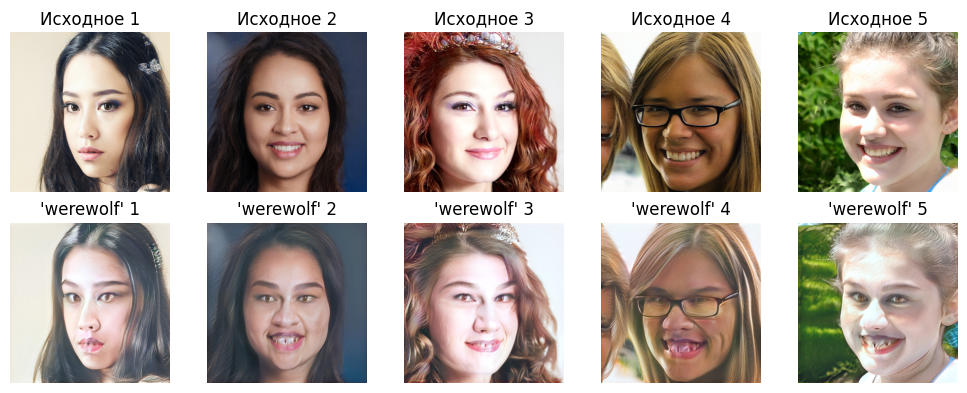

Валидационный пайплайн завершен.


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Эти переменные должны быть определены глобально или переданы
# latent_dim = 512
# checkpoint_path = 'stylegan2-ffhq-config-f.pt' # Или тот путь, который вы используете
# state_dict = torch.load(checkpoint_path, map_location=device)
resize = Resize((224, 224))
# Corrected std list to have 3 elements
normalize = Normalize(mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
# clip_model, _ = clip.load("ViT-B/32", device=device) # для функции apply_transformation

# ВАЖНО: Если у вас есть функции generate_latent_batch, tensor_to_image,
# direct_loss, CLIPLoss, убедитесь, что они либо скопированы,
# либо импортированы в ваш валидационный скрипт.

# --- Функции для сохранения/загрузки весов (будут ниже) ---
# save_model_weights(model, path)
# load_model_weights(model, path)

# --- Дополнительные функции для валидационного пайплайна ---

def generate_latent_batch(batch_size, device, generator_style_network):
    """
    Генерирует батч латентных векторов в W+ пространстве.
    Использует generator_style_network (generator.style) для отображения Z -> W+.
    """
    latent_z = torch.randn(batch_size, 512, device=device)
    with torch.no_grad():
        latent_w_plus = generator_style_network(latent_z)
    return latent_w_plus.detach().clone() # Отсоединяем, т.к. это будет вход для infer.

def tensor_to_image(tensor):
    """
    Преобразует тензор изображения из формата [-1, 1] в numpy [0, 1] для визуализации.
    """
    img = tensor[0].permute(1, 2, 0).cpu().numpy()
    img = (img + 1) / 2
    img = np.clip(img, 0, 1)
    return img

def visualize_transformation(generator_original, generator_transformed,
                             latent_batch, prompt1, prompt2,
                             num_samples=5):
    """
    Визуализирует изменения, примененные обученным генератором.

    :param generator_original: Исходный (замороженный) генератор.
    :param generator_transformed: Обученный (измененный) генератор.
    :param latent_batch: Батч латентных векторов для генерации.
    :param prompt1: Исходный текстовый промпт.
    :param prompt2: Целевой текстовый промпт.
    :param num_samples: Количество изображений для визуализации.
    """
    print(f"\n--- Визуализация трансформации: '{prompt1}' -> '{prompt2}' ---")

    generator_original.eval()
    generator_transformed.eval() # Переводим в eval для стабильности

    with torch.no_grad():
        # Генерируем изображения исходным генератором
        original_images, _ = generator_original(
            [latent_batch[:num_samples]], input_is_latent=True, randomize_noise=False
        )
        # Генерируем изображения трансформированным генератором
        transformed_images, _ = generator_transformed(
            [latent_batch[:num_samples]], input_is_latent=True, randomize_noise=False
        )

    fig, axs = plt.subplots(2, num_samples, figsize=(2 * num_samples, 4))

    for i in range(num_samples):
        # Исходные изображения (верхний ряд)
        axs[0, i].imshow(tensor_to_image(original_images[i].unsqueeze(0)))
        axs[0, i].set_title(f"Исходное {i+1}")
        axs[0, i].axis('off')

        # Измененные изображения (нижний ряд)
        axs[1, i].imshow(tensor_to_image(transformed_images[i].unsqueeze(0)))
        axs[1, i].set_title(f"'{prompt2}' {i+1}")
        axs[1, i].axis('off')

    plt.tight_layout()
    plt.show()

    generator_original.train() # Возвращаем в train, если они будут использоваться далее в обучении
    generator_transformed.train() # Возвращаем в train

# --- Основной скрипт валидации ---
def run_validation_pipeline(trained_model_path, original_model_filename,
                            num_viz_samples=5, target_prompt="werewolf", source_prompt="human"):

    print(f"Запуск валидационного пайплайна с моделью: {trained_model_path}")

    # Construct the full path to the original model weights
    current_dir = os.getcwd()
    original_model_path = os.path.join(current_dir, original_model_filename)

    # 1. Загрузка исходного генератора (замороженного)
    # Предполагается, что Generator уже определен и его путь к чекпоинту известен
    global latent_dim, device # Убедитесь, что они определены

    generator_original = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
    # Загружаем исходные веса для 'замороженного' генератора, чтобы иметь базу для сравнения
    original_state_dict = torch.load(original_model_path, map_location=device)
    generator_original.load_state_dict(original_state_dict['g_ema'] if 'g_ema' in original_state_dict else original_state_dict)
    generator_original.eval() # Переводим в режим оценки
    for param in generator_original.parameters(): # Замораживаем на всякий случай
        param.requires_grad_(False)
    print("Исходный генератор загружен и заморожен.")

    # 2. Загрузка обученной модели
    generator_trained = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
    load_model_weights(generator_trained, trained_model_path, device) # Pass the device argument
    generator_trained.eval() # Важно для инференса
    print(f"Обученный генератор загружен из {trained_model_path}.")

    # 3. Подготовка латентных векторов для визуализации
    # Используем style сеть оригинального генератора для получения W+ латентов
    fixed_latent_batch_for_viz = generate_latent_batch(num_viz_samples, device, generator_original.style)

    # 4. Визуализация трансформации
    visualize_transformation(generator_original, generator_trained,
                             fixed_latent_batch_for_viz, source_prompt, target_prompt,
                             num_samples=num_viz_samples)

    print("Валидационный пайплайн завершен.")

# Пример использования (раскомментировать и запустить после обучения/сохранения)
# ВАЖНО: убедитесь, что 'stylegan2-ffhq-config-f.pt' или аналогичный файл
# с базовыми весами доступен в той же директории, что и скрипт,
# или укажите полный путь к нему.
run_validation_pipeline(
    trained_model_path='/content/drive/MyDrive/trained_generator_werewolf.pt', # Имя файла, куда сохраните веса
    original_model_filename='stylegan2-ffhq-config-f.pt', # Имя файла исходных весов StyleGAN
    num_viz_samples=5,
    target_prompt="werewolf",
    source_prompt="human"
 )